<a href="https://colab.research.google.com/github/pradeep-ramola/AI-ML/blob/main/ML-Projects/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Exploratory Data Analysis

In [ ]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Loading Data from CSV

df = pd.read_csv("/content/Online_Retail.csv")

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [ ]:
"""
Agenda for the analysis:

- Product Level Analysis
- Revenue per Product per Year
- Quantity and Amount of Product sold across various cohorts
"""

'\nAgenda for the analysis:\n\n- Product Level Analysis\n- Revenue per Product per Year\n- Quantity and Amount of Product sold across various cohorts\n'

In [ ]:
"""
- Data Shape
- Data Types
- NULL Checks
- Granularity Level of Data
- Duplicates
- Other checks
"""

'\n- Data Shape\n- Data Types\n- NULL Checks\n- Granularity Level of Data\n- Duplicates\n- Other checks\n'

In [ ]:
# Checking the shape of Data
df.shape

(541909, 8)

In [ ]:
# Checking the datatype

df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
UnitPrice,float64
CustomerID,float64
Country,object


In [ ]:
# Null Check

df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
# How null data looks like

df[df['CustomerID'].isnull()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,01-12-2010 11:52,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,01-12-2010 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,01-12-2010 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,01-12-2010 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,01-12-2010 14:32,1.66,NaN,United Kingdom


In [ ]:
# Filling Null with Place holder

df['CustomerID'] = df['CustomerID'].fillna('007')
df['Description'] = df['Description'].fillna('None')

In [ ]:
# Items like

df[df['StockCode'].str.match(r"^C.+", na=False)].shape

(160, 8)

In [ ]:
# Cancelled orders has code C2

df[df['StockCode']=='C2'].shape

(144, 8)

In [ ]:
# Postage Charges has code POST

df[df['StockCode']=='POST'].shape

(1256, 8)

In [ ]:
# Removing Cancellation and POST as we are concerned with Product and Revenue

df.drop(df[df['StockCode'].isin(['POST', 'C2'])].index, inplace=True)

In [ ]:
# Checking if rows are dropped successfully

df[(df['StockCode'] == 'C2') | (df['StockCode'] == 'POST')].shape

(0, 8)

Granularity check

In [ ]:
# Handling InVoiceDate

# Convert to Datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format="%d-%m-%Y %H:%M")

# Extract Date
df['InvoiceDate'] = df['InvoiceDate'].dt.date

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,3.39,17850.0,United Kingdom


In [ ]:
len(df.groupby(['InvoiceNo', 'StockCode', 'InvoiceDate', 'CustomerID']).size())

529827

In [ ]:
len(df)

540509

In [ ]:
'''
Not the same? But Why?

- Duplicates
- NULL Customer IDs
- Difference in Descriptions
- Other Reasons
'''

'\nNot the same? But Why?\n\n- Duplicates\n- NULL Customer IDs\n- Difference in Descriptions\n- Other Reasons\n'

In [ ]:
duplicate_rows = df[df.duplicated(subset=["InvoiceNo", "StockCode", "InvoiceDate", "CustomerID"], keep=False)]

# Optional: sort to make it easier to inspect
duplicate_rows = duplicate_rows.sort_values(by=["InvoiceNo", "StockCode"])

duplicate_rows.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
113,536381,71270,PHOTO CLIP LINE,1,2010-12-01,1.25,15311.0,United Kingdom
125,536381,71270,PHOTO CLIP LINE,3,2010-12-01,1.25,15311.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01,2.95,17908.0,United Kingdom


In [ ]:
print("Rows before:", len(df))
df = df.drop_duplicates()
print("Rows after:", len(df))

Rows before: 540509
Rows after: 535240


In [ ]:
df = df.reset_index(drop=True)

In [ ]:
# Dropping the Description Column
df = df.drop(columns=['Description'])

In [ ]:
# Aggregating based on Quantity

df = (
    df.groupby(
        ["InvoiceNo", "StockCode", "InvoiceDate", "UnitPrice", "CustomerID", "Country"],
        as_index=False
    )["Quantity"].sum()
)

print(df.shape)

(530401, 7)


In [ ]:
# 529827 vs 530401

In [ ]:
df.head()

,InvoiceNo,StockCode,InvoiceDate,UnitPrice,CustomerID,Country,Quantity
0,536365,21730,2010-12-01,4.25,17850.0,United Kingdom,6
1,536365,22752,2010-12-01,7.65,17850.0,United Kingdom,2
2,536365,71053,2010-12-01,3.39,17850.0,United Kingdom,6
3,536365,84029E,2010-12-01,3.39,17850.0,United Kingdom,6
4,536365,84029G,2010-12-01,3.39,17850.0,United Kingdom,6


In [ ]:
len(df.groupby(['InvoiceNo', 'StockCode', 'InvoiceDate', 'CustomerID', 'Country']).size())

529827

In [ ]:
# Removing the Unit Price Descripency

df = df.loc[
    df.groupby(["InvoiceNo", "StockCode", "CustomerID", "InvoiceDate"])["Quantity"].idxmax()
].reset_index(drop=True)

print("Rows after keeping max Quantity per group:", df.shape[0])

Rows after keeping max Quantity per group: 529827


In [ ]:
df[df["CustomerID"]=='007'].head()

,InvoiceNo,StockCode,InvoiceDate,UnitPrice,CustomerID,Country,Quantity
576,536414,22139,2010-12-01,0.00,007,United Kingdom,56
1348,536544,11001,2010-12-01,3.36,007,United Kingdom,3
1349,536544,16236,2010-12-01,0.43,007,United Kingdom,1
1350,536544,16237,2010-12-01,0.43,007,United Kingdom,4
1351,536544,16238,2010-12-01,0.43,007,United Kingdom,1


Product Level Analysis

In [ ]:
# Going to Product Level

df_product = df.groupby(["StockCode", "InvoiceDate", "Country"], as_index=False).agg({
    "Quantity": "sum",
    "UnitPrice": "mean"
})

In [ ]:
df_product["Revenue"] = df_product["Quantity"] * df_product["UnitPrice"]

In [ ]:
df_product.head()

,StockCode,InvoiceDate,Country,Quantity,UnitPrice,Revenue
0,10002,2010-12-01,France,48,0.85,40.80
1,10002,2010-12-01,United Kingdom,12,0.85,10.20
2,10002,2010-12-02,United Kingdom,1,0.85,0.85
3,10002,2010-12-03,United Kingdom,8,1.39,11.12
4,10002,2010-12-05,United Kingdom,1,0.85,0.85


                 Country       Revenue
36        United Kingdom  8.714230e+06
24           Netherlands  2.831675e+05
10                  EIRE  2.567698e+05
14               Germany  2.011515e+05
13                France  1.821922e+05
0              Australia  1.369225e+05
33           Switzerland  5.249425e+04
31                 Spain  4.890403e+04
3                Belgium  3.666296e+04
20                 Japan  3.534062e+04
32                Sweden  3.519641e+04
25                Norway  3.202506e+04
27              Portugal  2.593878e+04
6        Channel Islands  1.992639e+04
12               Finland  1.880194e+04
9                Denmark  1.800089e+04
19                 Italy  1.524551e+04
7                 Cyprus  1.284376e+04
16             Hong Kong  9.685540e+03
30             Singapore  9.120390e+03
1                Austria  8.698320e+03
18                Israel  7.901970e+03
26                Poland  6.853140e+03
37           Unspecified  4.740940e+03
15                Greece 

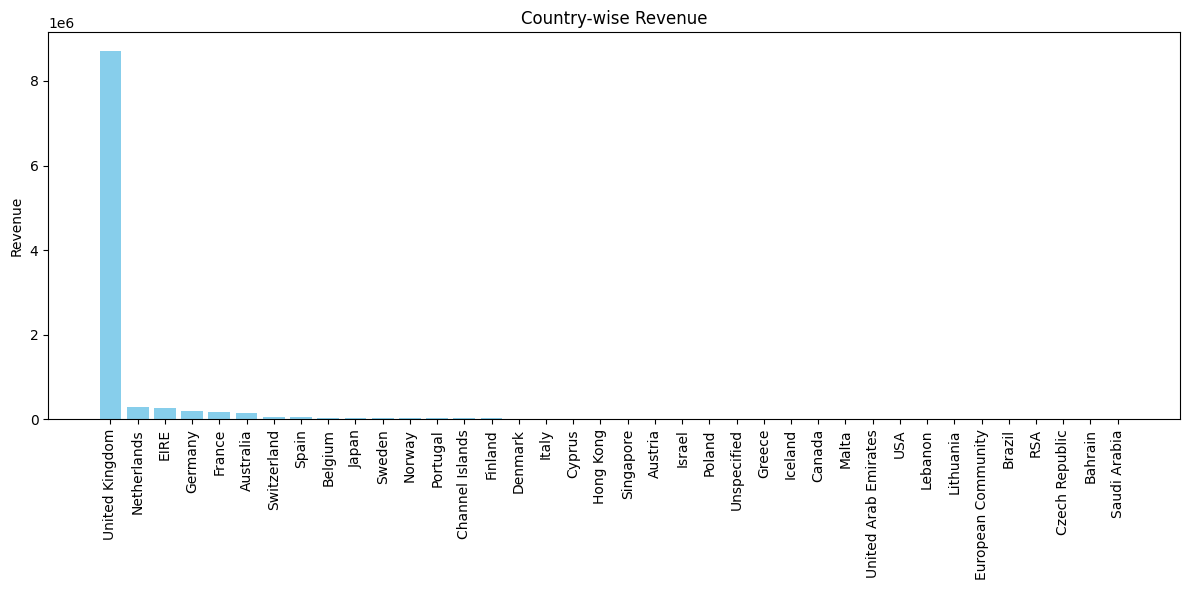

In [ ]:
# Country

import pandas as pd
import matplotlib.pyplot as plt

# Ensure Revenue column exists
df_product["Revenue"] = df_product["Quantity"] * df_product["UnitPrice"]

# Aggregate revenue by Country
country_revenue = df_product.groupby("Country", as_index=False)["Revenue"].sum()

# Sort descending
country_revenue = country_revenue.sort_values(by="Revenue", ascending=False)

# Display table
print(country_revenue)

# Plot bar chart
plt.figure(figsize=(12,6))
plt.bar(country_revenue["Country"], country_revenue["Revenue"], color="skyblue")
plt.xticks(rotation=90)
plt.ylabel("Revenue")
plt.title("Country-wise Revenue")
plt.tight_layout()
plt.show()

           Region       Revenue
0           Other  1.484014e+06
1  United Kingdom  8.714230e+06


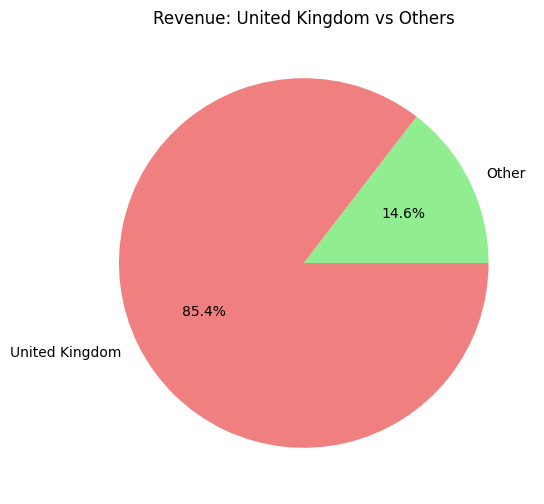

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure Revenue column exists
df_product["Revenue"] = df_product["Quantity"] * df_product["UnitPrice"]

# Create a new column to flag UK vs Others
df_product["Region"] = df_product["Country"].apply(lambda x: "United Kingdom" if x == "United Kingdom" else "Other")

# Aggregate revenue by Region
region_revenue = df_product.groupby("Region", as_index=False)["Revenue"].sum()

# Display table
print(region_revenue)

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(region_revenue["Revenue"], labels=region_revenue["Region"], autopct="%1.1f%%", colors=["lightgreen", "lightcoral"])
plt.title("Revenue: United Kingdom vs Others")
plt.show()

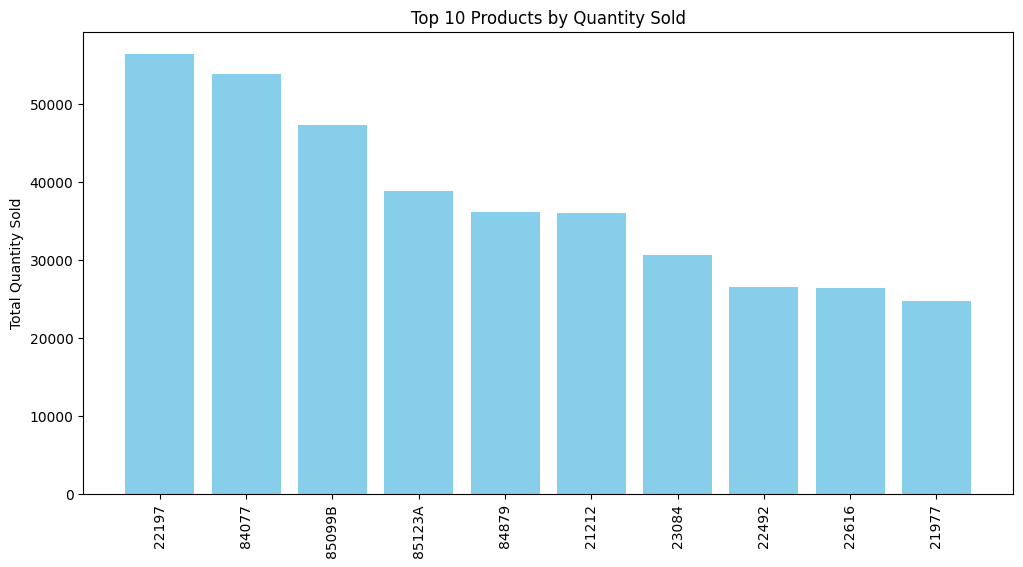

In [ ]:
# Top 10 Products by Quantity Sold

top_qty = df_product.groupby("StockCode", as_index=False)["Quantity"].sum()
top_qty = top_qty.sort_values("Quantity", ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(top_qty["StockCode"], top_qty["Quantity"], color="skyblue")
plt.xticks(rotation=90)
plt.ylabel("Total Quantity Sold")
plt.title("Top 10 Products by Quantity Sold")
plt.show()

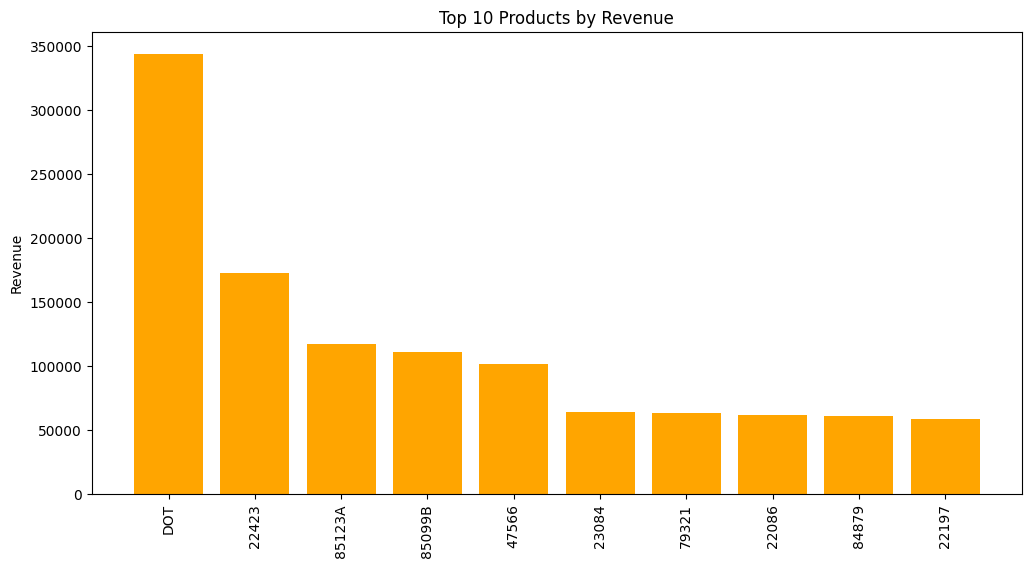

In [ ]:
# Top 10 by Revenue

top_revenue = df_product.groupby("StockCode", as_index=False)["Revenue"].sum()
top_revenue = top_revenue.sort_values("Revenue", ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(top_revenue["StockCode"], top_revenue["Revenue"], color="orange")
plt.xticks(rotation=90)
plt.ylabel("Revenue")
plt.title("Top 10 Products by Revenue")
plt.show()

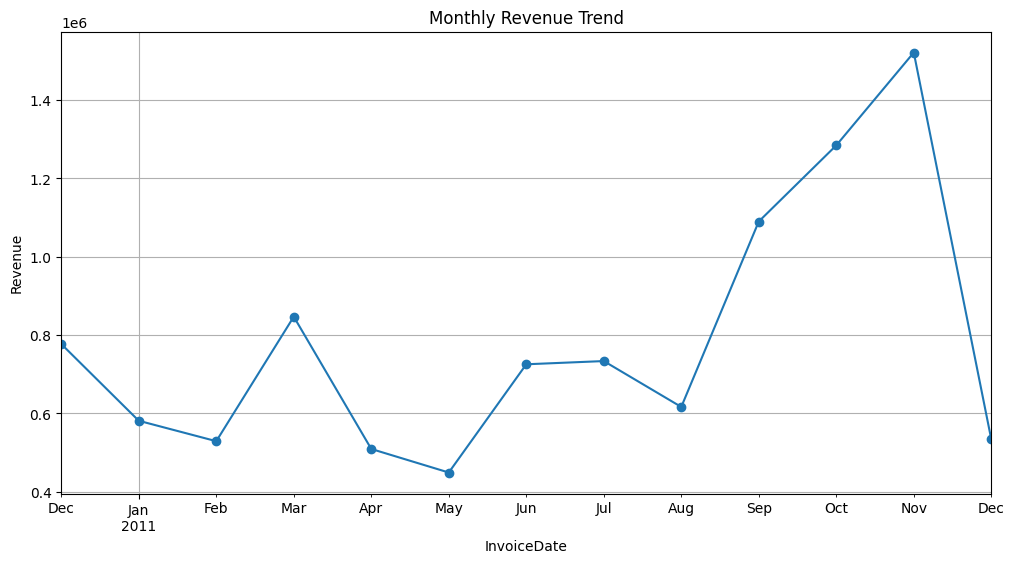

In [ ]:
# Monthly Revenue Trend

df_product["InvoiceDate"] = pd.to_datetime(df_product["InvoiceDate"])
monthly_revenue = df_product.groupby(df_product["InvoiceDate"].dt.to_period("M"))["Revenue"].sum()

monthly_revenue.plot(kind="line", figsize=(12,6), marker="o")
plt.ylabel("Revenue")
plt.title("Monthly Revenue Trend")
plt.grid(True)
plt.show()